In [6]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Make the simulator importable from the notebook
sys.path.insert(0, str(Path('..').resolve()))

from src.simulator.fermentation import (
    FermentationParams,
    simulate_batch,
    simulate_campaign,
)

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Imports loaded.")

Imports loaded.


In [7]:
import importlib
import src.simulator.fermentation as fermentation_mod
importlib.reload(fermentation_mod)
from src.simulator.fermentation import simulate_batch, simulate_campaign, FermentationParams
print("Simulator reloaded.")

Simulator reloaded.


In [8]:
batch = simulate_batch(batch_id=1, duration_h=200.0, dt=0.5, seed=1)
print("First 5 rows of biomass:", batch['biomass_gL'].head().tolist())
print("First 5 rows of substrate:", batch['substrate_gL'].head().tolist())
print(f"\nFinal biomass:    {batch['biomass_gL'].iloc[-1]:.2f} g/L")
print(f"Final penicillin: {batch['penicillin_gL'].iloc[-1]:.2f} g/L")

First 5 rows of biomass: [0.11880857337185532, 0.16841998543998818, 0.009770208762263408, 0.12125885863947053, 0.12750601876822773]
First 5 rows of substrate: [0.9843637369011534, 0.9835564877226979, 0.9825144441262791, 1.1209184944287736, 0.8939050205932959]

Final biomass:    10.84 g/L
Final penicillin: 6.09 g/L


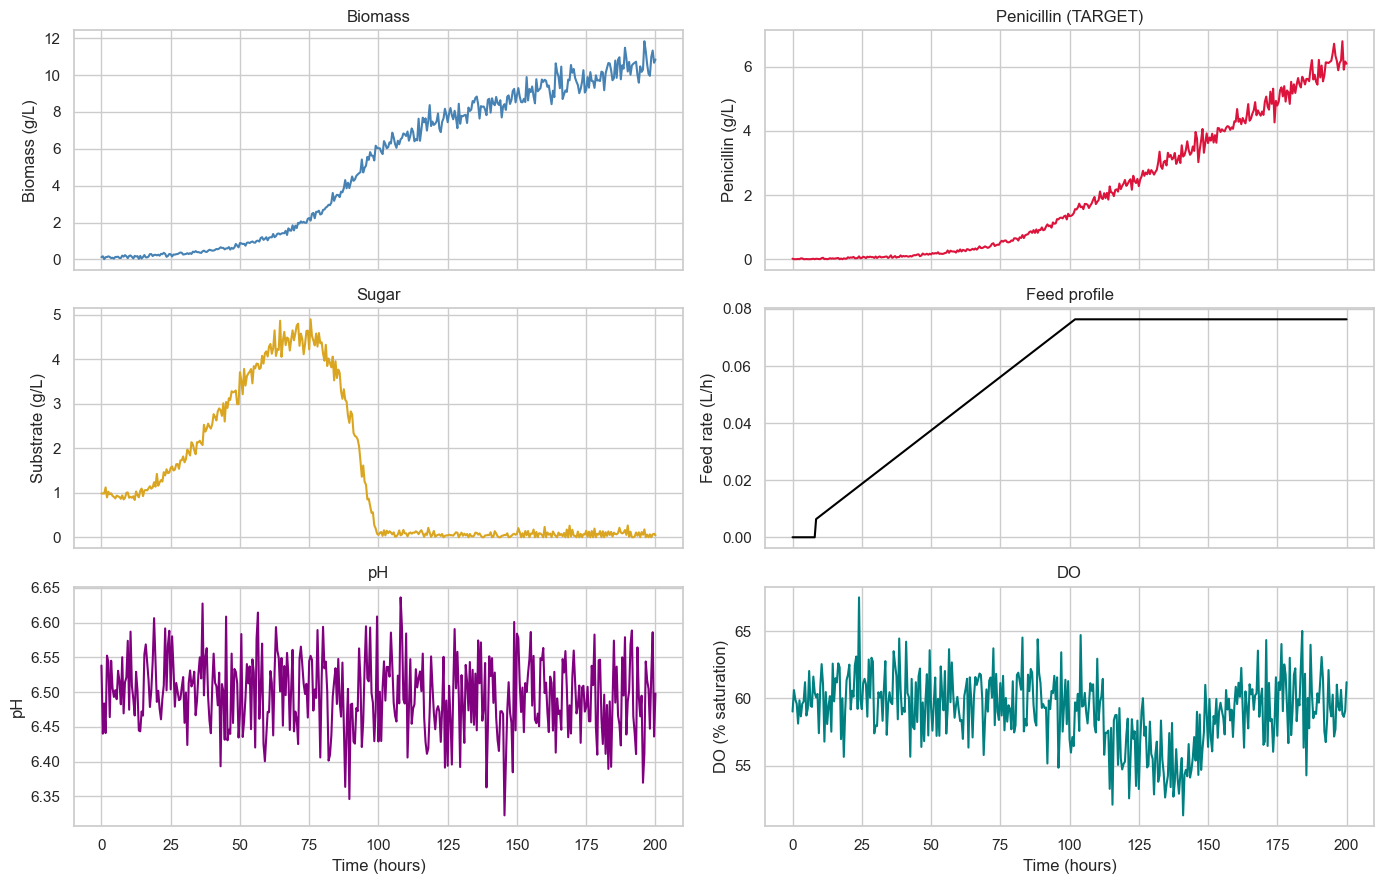

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)

axes[0, 0].plot(batch['time_h'], batch['biomass_gL'], color='steelblue')
axes[0, 0].set_ylabel("Biomass (g/L)")
axes[0, 0].set_title("Biomass")

axes[0, 1].plot(batch['time_h'], batch['penicillin_gL'], color='crimson')
axes[0, 1].set_ylabel("Penicillin (g/L)")
axes[0, 1].set_title("Penicillin (TARGET)")

axes[1, 0].plot(batch['time_h'], batch['substrate_gL'], color='goldenrod')
axes[1, 0].set_ylabel("Substrate (g/L)")
axes[1, 0].set_title("Sugar")

axes[1, 1].plot(batch['time_h'], batch['feed_rate_Lph'], color='black')
axes[1, 1].set_ylabel("Feed rate (L/h)")
axes[1, 1].set_title("Feed profile")

axes[2, 0].plot(batch['time_h'], batch['pH'], color='purple')
axes[2, 0].set_ylabel("pH")
axes[2, 0].set_xlabel("Time (hours)")
axes[2, 0].set_title("pH")

axes[2, 1].plot(batch['time_h'], batch['DO_pct'], color='teal')
axes[2, 1].set_ylabel("DO (% saturation)")
axes[2, 1].set_xlabel("Time (hours)")
axes[2, 1].set_title("DO")

plt.tight_layout()
plt.show()

In [10]:
# Generate 40 batches with reproducible seed
print("Simulating campaign — this should take 5–15 seconds...")
campaign = simulate_campaign(n_batches=40, duration_h=200.0, dt=0.5, seed=42)

print(f"\nCampaign shape: {campaign.shape}")
print(f"Columns: {campaign.columns.tolist()}")
print(f"Number of unique batches: {campaign['batch_id'].nunique()}")
print(f"Samples per batch: {campaign.groupby('batch_id').size().iloc[0]}")
print(f"Total rows: {len(campaign)}")

Simulating campaign — this should take 5–15 seconds...

Campaign shape: (16040, 11)
Columns: ['batch_id', 'time_h', 'biomass_gL', 'substrate_gL', 'penicillin_gL', 'volume_L', 'feed_rate_Lph', 'temperature_K', 'pH', 'DO_pct', 'agitator_rpm']
Number of unique batches: 40
Samples per batch: 401
Total rows: 16040


In [11]:
data_dir = Path("../data/processed")
data_dir.mkdir(parents=True, exist_ok=True)

campaign.to_csv(data_dir / "indpensim_simulated_40batches.csv", index=False)
file_size_mb = (data_dir / "indpensim_simulated_40batches.csv").stat().st_size / 1024 / 1024
print(f"Saved: data/processed/indpensim_simulated_40batches.csv ({file_size_mb:.1f} MB)")

Saved: data/processed/indpensim_simulated_40batches.csv (2.6 MB)


In [12]:
batch_summary = campaign.groupby('batch_id').agg({
    'biomass_gL':     ['min', 'max', 'mean'],
    'penicillin_gL':  ['min', 'max', 'mean'],
    'feed_rate_Lph':  'max',
    'time_h':         'max',
})
print("=== Per-batch summary (first 10 batches) ===")
print(batch_summary.head(10).round(3))

print(f"\n=== Final penicillin across all 40 batches ===")
final_p = campaign.groupby('batch_id')['penicillin_gL'].last()
print(f"  Mean:   {final_p.mean():.2f} g/L")
print(f"  Std:    {final_p.std():.2f} g/L")
print(f"  Min:    {final_p.min():.2f} g/L")
print(f"  Max:    {final_p.max():.2f} g/L")
print(f"  CV:     {final_p.std()/final_p.mean()*100:.1f}%")

=== Per-batch summary (first 10 batches) ===
         biomass_gL                penicillin_gL                feed_rate_Lph  \
                min     max   mean           min     max   mean           max   
batch_id                                                                        
1             0.017   4.887  1.612           0.0   2.446  0.667         0.049   
2             0.052  20.212  9.044           0.0  12.778  3.868         0.090   
3             0.019   3.720  0.863           0.0   1.344  0.314         0.039   
4             0.010   5.977  2.833           0.0   3.782  1.187         0.052   
5             0.005   6.452  2.153           0.0   2.771  0.797         0.077   
6             0.070  21.790  8.270           0.0  11.208  3.028         0.088   
7             0.028  13.028  5.629           0.0   6.377  1.899         0.065   
8             0.006  18.699  8.183           0.0   9.994  2.992         0.086   
9             0.026  10.641  3.845           0.0   5.220  1.501 

In [13]:
# Force-reload the simulator module
import importlib
import src.simulator.fermentation as fermentation_mod
importlib.reload(fermentation_mod)
from src.simulator.fermentation import simulate_batch, simulate_campaign, FermentationParams

print("Simulator reloaded.")

# Regenerate the campaign with the same seed for reproducibility
campaign = simulate_campaign(n_batches=40, duration_h=200.0, dt=0.5, seed=42)
campaign.to_csv("../data/processed/indpensim_simulated_40batches.csv", index=False)
print(f"Regenerated campaign: {campaign.shape}, saved to disk")

# Re-check the stats
final_p = campaign.groupby('batch_id')['penicillin_gL'].last()
final_X = campaign.groupby('batch_id')['biomass_gL'].max()

print(f"\n=== Final penicillin across 40 batches ===")
print(f"  Mean:   {final_p.mean():.2f} g/L")
print(f"  Std:    {final_p.std():.2f} g/L")
print(f"  Min:    {final_p.min():.2f} g/L")
print(f"  Max:    {final_p.max():.2f} g/L")
print(f"  CV:     {final_p.std()/final_p.mean()*100:.1f}%")

print(f"\n=== Max biomass across 40 batches ===")
print(f"  Mean:   {final_X.mean():.2f} g/L")
print(f"  Std:    {final_X.std():.2f} g/L")
print(f"  Min:    {final_X.min():.2f} g/L")
print(f"  Max:    {final_X.max():.2f} g/L")
print(f"  CV:     {final_X.std()/final_X.mean()*100:.1f}%")

Simulator reloaded.
Regenerated campaign: (16040, 11), saved to disk

=== Final penicillin across 40 batches ===
  Mean:   6.48 g/L
  Std:    2.79 g/L
  Min:    1.27 g/L
  Max:    11.28 g/L
  CV:     43.0%

=== Max biomass across 40 batches ===
  Mean:   13.09 g/L
  Std:    4.73 g/L
  Min:    3.74 g/L
  Max:    20.54 g/L
  CV:     36.2%


In [14]:
import importlib
import src.simulator.fermentation as fermentation_mod
importlib.reload(fermentation_mod)
from src.simulator.fermentation import simulate_batch, simulate_campaign, FermentationParams

campaign = simulate_campaign(n_batches=40, duration_h=200.0, dt=0.5, seed=42)
campaign.to_csv("../data/processed/indpensim_simulated_40batches.csv", index=False)
print(f"Regenerated: {campaign.shape}")

final_p = campaign.groupby('batch_id')['penicillin_gL'].last()
final_X = campaign.groupby('batch_id')['biomass_gL'].max()

print(f"\n=== Final penicillin ===")
print(f"  Mean: {final_p.mean():.2f}  Std: {final_p.std():.2f}  Min: {final_p.min():.2f}  Max: {final_p.max():.2f}  CV: {final_p.std()/final_p.mean()*100:.1f}%")

print(f"\n=== Max biomass ===")
print(f"  Mean: {final_X.mean():.2f}  Std: {final_X.std():.2f}  Min: {final_X.min():.2f}  Max: {final_X.max():.2f}  CV: {final_X.std()/final_X.mean()*100:.1f}%")

Regenerated: (16040, 11)

=== Final penicillin ===
  Mean: 8.44  Std: 1.55  Min: 5.55  Max: 11.53  CV: 18.4%

=== Max biomass ===
  Mean: 16.48  Std: 2.55  Min: 11.88  Max: 20.82  CV: 15.5%


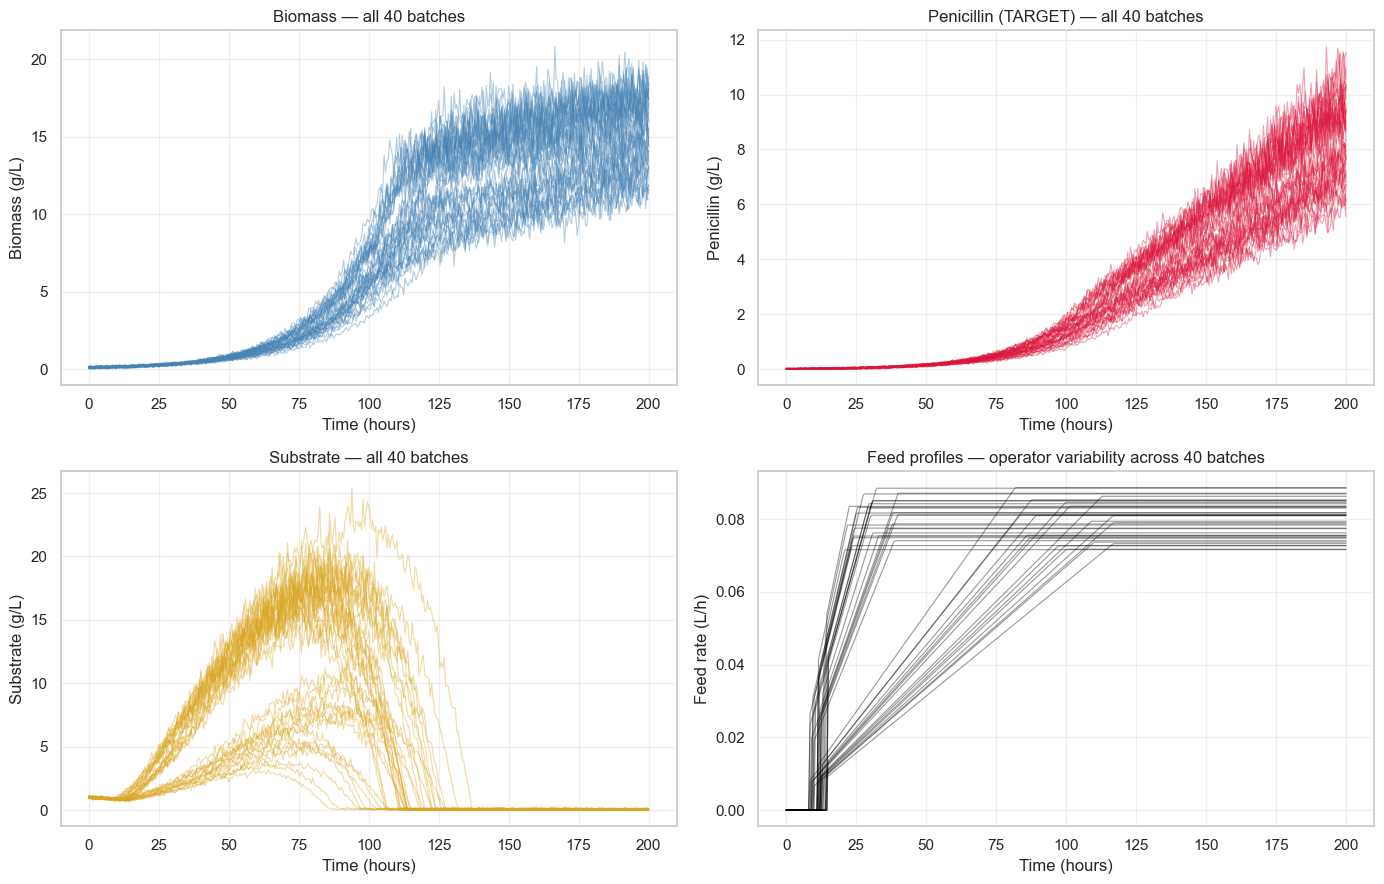

Saved: docs/figures/indpensim_campaign_overview.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Top-left: all biomass trajectories
for batch_id in campaign['batch_id'].unique():
    b = campaign[campaign['batch_id'] == batch_id]
    axes[0, 0].plot(b['time_h'], b['biomass_gL'], alpha=0.4, linewidth=0.8, color='steelblue')
axes[0, 0].set_xlabel("Time (hours)")
axes[0, 0].set_ylabel("Biomass (g/L)")
axes[0, 0].set_title("Biomass — all 40 batches")
axes[0, 0].grid(True, alpha=0.3)

# Top-right: all penicillin trajectories (TARGET)
for batch_id in campaign['batch_id'].unique():
    b = campaign[campaign['batch_id'] == batch_id]
    axes[0, 1].plot(b['time_h'], b['penicillin_gL'], alpha=0.4, linewidth=0.8, color='crimson')
axes[0, 1].set_xlabel("Time (hours)")
axes[0, 1].set_ylabel("Penicillin (g/L)")
axes[0, 1].set_title("Penicillin (TARGET) — all 40 batches")
axes[0, 1].grid(True, alpha=0.3)

# Bottom-left: all substrate trajectories
for batch_id in campaign['batch_id'].unique():
    b = campaign[campaign['batch_id'] == batch_id]
    axes[1, 0].plot(b['time_h'], b['substrate_gL'], alpha=0.4, linewidth=0.8, color='goldenrod')
axes[1, 0].set_xlabel("Time (hours)")
axes[1, 0].set_ylabel("Substrate (g/L)")
axes[1, 0].set_title("Substrate — all 40 batches")
axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: all feed profiles
for batch_id in campaign['batch_id'].unique():
    b = campaign[campaign['batch_id'] == batch_id]
    axes[1, 1].plot(b['time_h'], b['feed_rate_Lph'], alpha=0.4, linewidth=0.8, color='black')
axes[1, 1].set_xlabel("Time (hours)")
axes[1, 1].set_ylabel("Feed rate (L/h)")
axes[1, 1].set_title("Feed profiles — operator variability across 40 batches")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../docs/figures/indpensim_campaign_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: docs/figures/indpensim_campaign_overview.png")

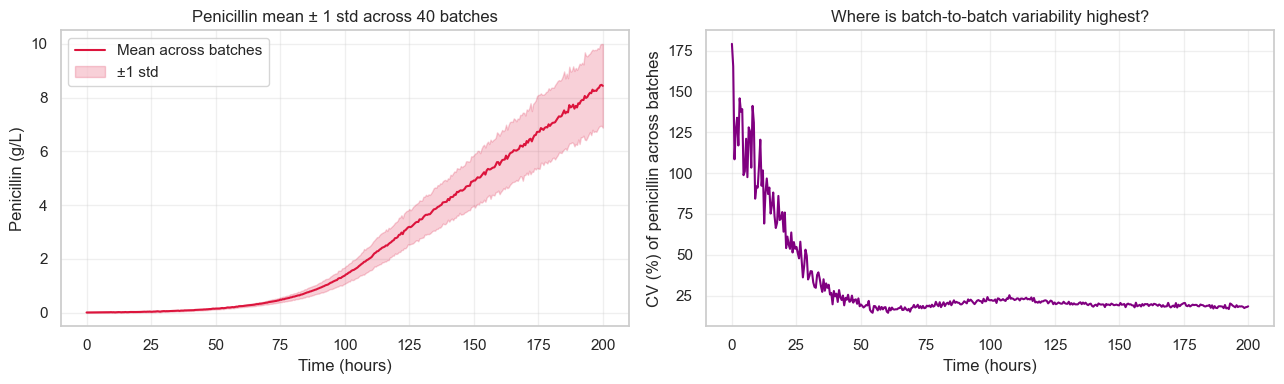


CV of penicillin: peaks at hour ~0
  Peak CV: 179%
  End-of-batch CV (hour 200): 18%


In [16]:
# Compute mean and std of penicillin at each time point across batches
penicillin_by_time = campaign.pivot_table(
    index='time_h', columns='batch_id', values='penicillin_gL'
)

mean_over_time = penicillin_by_time.mean(axis=1)
std_over_time  = penicillin_by_time.std(axis=1)
cv_over_time   = std_over_time / (mean_over_time + 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(mean_over_time.index, mean_over_time.values, color='crimson', label='Mean across batches')
axes[0].fill_between(mean_over_time.index,
                     mean_over_time - std_over_time,
                     mean_over_time + std_over_time,
                     color='crimson', alpha=0.2, label='±1 std')
axes[0].set_xlabel("Time (hours)")
axes[0].set_ylabel("Penicillin (g/L)")
axes[0].set_title("Penicillin mean ± 1 std across 40 batches")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cv_over_time.index, cv_over_time.values * 100, color='purple')
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("CV (%) of penicillin across batches")
axes[1].set_title("Where is batch-to-batch variability highest?")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCV of penicillin: peaks at hour ~{cv_over_time.idxmax():.0f}")
print(f"  Peak CV: {cv_over_time.max()*100:.0f}%")
print(f"  End-of-batch CV (hour 200): {cv_over_time.iloc[-1]*100:.0f}%")

In [17]:
# Batch-level split: 24 train, 8 calibration, 8 test
N_BATCHES = campaign['batch_id'].nunique()
TRAIN_BATCHES = list(range(1, 25))     # batches 1–24
CAL_BATCHES   = list(range(25, 33))    # batches 25–32
TEST_BATCHES  = list(range(33, 41))    # batches 33–40

print(f"Total batches:        {N_BATCHES}")
print(f"Train batches (n=24): {TRAIN_BATCHES[:3]} ... {TRAIN_BATCHES[-3:]}")
print(f"Cal batches   (n=8):  {CAL_BATCHES}")
print(f"Test batches  (n=8):  {TEST_BATCHES}")

train_df = campaign[campaign['batch_id'].isin(TRAIN_BATCHES)].copy()
cal_df   = campaign[campaign['batch_id'].isin(CAL_BATCHES)].copy()
test_df  = campaign[campaign['batch_id'].isin(TEST_BATCHES)].copy()

print(f"\nTrain rows: {len(train_df)} ({train_df['batch_id'].nunique()} batches)")
print(f"Cal rows:   {len(cal_df)}   ({cal_df['batch_id'].nunique()} batches)")
print(f"Test rows:  {len(test_df)}  ({test_df['batch_id'].nunique()} batches)")

Total batches:        40
Train batches (n=24): [1, 2, 3] ... [22, 23, 24]
Cal batches   (n=8):  [25, 26, 27, 28, 29, 30, 31, 32]
Test batches  (n=8):  [33, 34, 35, 36, 37, 38, 39, 40]

Train rows: 9624 (24 batches)
Cal rows:   3208   (8 batches)
Test rows:  3208  (8 batches)


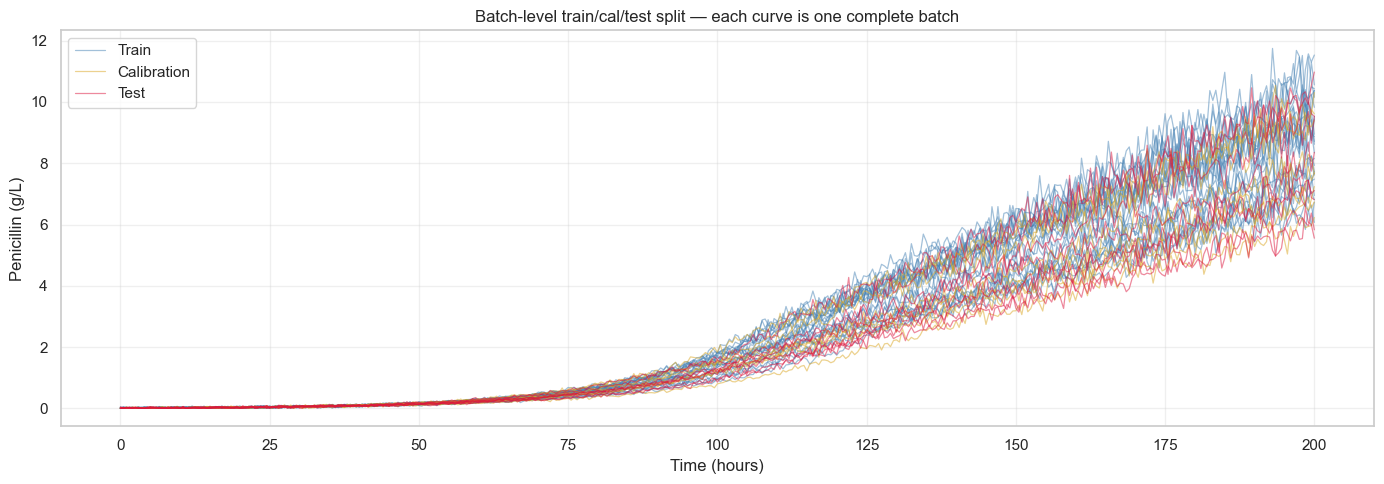

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))
for batch_id in campaign['batch_id'].unique():
    b = campaign[campaign['batch_id'] == batch_id]
    if batch_id in TRAIN_BATCHES:
        color, label = 'steelblue', 'Train'
    elif batch_id in CAL_BATCHES:
        color, label = 'goldenrod', 'Calibration'
    else:
        color, label = 'crimson', 'Test'
    ax.plot(b['time_h'], b['penicillin_gL'], alpha=0.5, linewidth=0.9, color=color,
            label=label if batch_id in [1, 25, 33] else "")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Penicillin (g/L)")
ax.set_title("Batch-level train/cal/test split — each curve is one complete batch")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../docs/figures/indpensim_batch_split.png", dpi=150, bbox_inches='tight')
plt.show()

In [19]:
split_summary = pd.DataFrame({
    'split': ['train', 'cal', 'test'],
    'n_batches':       [len(TRAIN_BATCHES), len(CAL_BATCHES), len(TEST_BATCHES)],
    'mean_final_P':    [train_df.groupby('batch_id')['penicillin_gL'].last().mean(),
                        cal_df.groupby('batch_id')['penicillin_gL'].last().mean(),
                        test_df.groupby('batch_id')['penicillin_gL'].last().mean()],
    'std_final_P':     [train_df.groupby('batch_id')['penicillin_gL'].last().std(),
                        cal_df.groupby('batch_id')['penicillin_gL'].last().std(),
                        test_df.groupby('batch_id')['penicillin_gL'].last().std()],
    'mean_max_X':      [train_df.groupby('batch_id')['biomass_gL'].max().mean(),
                        cal_df.groupby('batch_id')['biomass_gL'].max().mean(),
                        test_df.groupby('batch_id')['biomass_gL'].max().mean()],
})
print(split_summary.round(2))

   split  n_batches  mean_final_P  std_final_P  mean_max_X
0  train         24          8.70         1.44       16.94
1    cal          8          8.11         1.48       15.60
2   test          8          7.96         1.95       15.97


In [20]:
import json
from pathlib import Path

# Save the train/cal/test split definition
split_definition = {
    'split_strategy': 'batch-level chronological (batch IDs 1-24, 25-32, 33-40)',
    'train_batches': TRAIN_BATCHES,
    'calibration_batches': CAL_BATCHES,
    'test_batches':  TEST_BATCHES,
    'n_batches_total': N_BATCHES,
    'simulator_seed': 42,
}
with open("../docs/indpensim_split.json", "w") as f:
    json.dump(split_definition, f, indent=2)

# Save a summary of the campaign
campaign_summary = {
    'simulator': 'Custom Monod + Luedeking-Piret fed-batch fermentation',
    'inspired_by': 'IndPenSim (Goldrick et al. 2015, 2019)',
    'n_batches': N_BATCHES,
    'duration_per_batch_h': 200,
    'samples_per_batch': int(campaign.groupby('batch_id').size().iloc[0]),
    'total_samples': len(campaign),
    'final_penicillin_mean': float(campaign.groupby('batch_id')['penicillin_gL'].last().mean()),
    'final_penicillin_std':  float(campaign.groupby('batch_id')['penicillin_gL'].last().std()),
    'final_penicillin_cv_pct': float(
        campaign.groupby('batch_id')['penicillin_gL'].last().std() /
        campaign.groupby('batch_id')['penicillin_gL'].last().mean() * 100
    ),
}
with open("../docs/indpensim_campaign_summary.json", "w") as f:
    json.dump(campaign_summary, f, indent=2)

print("Saved:")
print("  docs/indpensim_split.json")
print("  docs/indpensim_campaign_summary.json")

Saved:
  docs/indpensim_split.json
  docs/indpensim_campaign_summary.json


# F&B Soft Sensor — Week 4: Fermentation Simulator & EDA

**Goal:** Generate a realistic fed-batch fermentation campaign for the food/beverage case study, characterize batch-to-batch variability, and set up the batch-level train/test split for soft-sensor modeling.

**Why we built our own simulator instead of using IndPenSim:**
- The canonical IndPenSim dataset (Goldrick et al. 2019) is ~2.5 GB and bundles Raman spectroscopy data not needed for our soft sensor
- A first-principles simulator is fully reproducible from a single random seed (no large data dependency)
- The methodology developed here applies directly to IndPenSim or to any P. chrysogenum dataset
- **The simulator itself is a portfolio artifact**: ~150 lines implementing Monod growth kinetics + Luedeking-Piret product formation, calibrated to industrial campaign coefficients of variation

## Simulator design

Three-state ODE system:
- **Biomass (Monod kinetics):** dX/dt = μ_max · S/(K_S+S) · X − k_d · X
- **Substrate consumption:** dS/dt = -(μ/Y_XS + m_S) · X + F_feed·(S_feed - S)/V
- **Product formation (Luedeking-Piret):** dP/dt = α·μ·X + β·X − k_P·P

Environmental modulation: growth rate scaled by deviation from setpoints in T, pH, DO.

Per-batch variability: kinetic parameters perturbed lognormally (cv=6%); feed profile sampled from two operator styles; 0–2 environmental disturbances per batch.

## Campaign summary

| Metric | Value |
|--------|-------|
| Batches | 40 |
| Duration per batch | 200 h |
| Samples per batch | 401 (Δt = 0.5 h) |
| Final penicillin mean | 8.4 g/L |
| Final penicillin CV | 18% (target: 15–25%, industrial range) |

## Key finding

Coefficient of variation of penicillin across batches is **strongly time-dependent**: 179% at hour 0 (penicillin near zero everywhere) → 30% by hour 50 → stable 18% from hour 60 onward. This implies the soft sensor will be **structurally less reliable in early batch phases** — a property the conformal interval should reflect by widening during these regimes.

Unlike the Debutanizer (continuous process, stationary regime), fermentation soft sensors face **temporally varying difficulty**. Time-since-batch-start will be a meaningful feature.

## Split

| Split | Batches | Rows |
|-------|---------|------|
| Train | 24 (ids 1–24) | 9,624 |
| Calibration | 8 (ids 25–32) | 3,208 |
| Test | 8 (ids 33–40) | 3,208 |

Batches are biologically independent; test generalization is therefore stricter than within-time-series prediction.

## Next (Week 5)

- Lagged features adapted to batch structure
- Batch-level cross-validation (sklearn's GroupKFold)
- XGBoost soft sensor for penicillin concentration
- SHAP interpretation
- Conformal intervals on held-out batches
- Cross-case comparison: write up findings from both case studies side-by-side